In [2]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# 1. Loading
df = pd.read_csv('cleaned_drug_side_effects.csv')

# Utility function to transform strings "A;B;C" into lists ['A', 'B', 'C']
def split_items(x):
   return x.split(';') if pd.notnull(x) else []

# Transform the column into a list
df['targets_list'] = df['targets'].apply(split_items)

# MultiLabelBinarizer creates one column per possible target
mlb_targets = MultiLabelBinarizer()
X_targets = mlb_targets.fit_transform(df['targets_list'])
print(f"Shape of 'targets' features: {X_targets.shape}") 
# Expected result: (1052, ~1148)

Shape of 'targets' features: (1052, 1400)


# Encoding Names (Explanatory Variables)
We use TF-IDF on characters (n-grams of size 3 to 5).

Capturing roots like "meth", "oxy", "zole".
analyzer='char': Instead of reading entire words (like "cat", "dog"), the algorithm will read characters (letters).

This is crucial because drug names do not have "sentences", the meaning is hidden within the word itself. ngram_range=(3, 5): This instructs the algorithm to create a sliding window that captures groups of 3, 4, and 5 consecutive letters.

In [3]:
# Using TF-IDF Vectorizer with character n-grams (3 to 5 letters)
tfidf = TfidfVectorizer(analyzer='char', ngram_range=(3, 5))

# Fit: It scans through the entire drug_name column, splits all names into n-grams (3 to 5 letters) and builds a gigantic dictionary of all existing combinations (e.g., azep, zepa, epam...)
# Transform: It replaces each drug name with a numerical vector (a sequence of numbers)
X_names = tfidf.fit_transform(df['drug_name'])

print(f"Shape of 'names' features: {X_names.shape}")

Shape of 'names' features: (1052, 10205)


In [4]:
# Transform the column into a list
df['side_effects_list'] = df['side_effect'].apply(split_items)

# MultiLabelBinarizer creates one column per possible side effect
mlb_effects = MultiLabelBinarizer()
y = mlb_effects.fit_transform(df['side_effects_list'])

# Print the shape of the target variable
print(f"Shape of the target 'y': {y.shape}")
# Expected result: (1052, ~5735)

Shape of the target 'y': (1052, 5735)


In [5]:


# --- D. Fusion for the model ---
# To obtain your final matrix X, concatenate the features
X_final = np.hstack([X_targets, X_names.toarray()])

print(f"Final matrix for training: {X_final.shape}")
print(f"First rows of the final matrix X_final:\n{X_final[:5]}")  # Displays the first 5 rows and 5 columns

Final matrix for training: (1052, 11605)
First rows of the final matrix X_final:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


Shape of Syntactic Similarity feature (X_sim): (1052, 1)
First 5 similarity scores: [0.24       0.33333333 0.30434783 0.25       0.26666667]


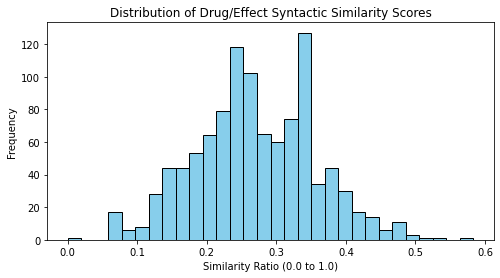

In [8]:
import difflib
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, make_scorer
import numpy as np
import matplotlib.pyplot as plt

# --- E. Syntactic Similarity Feature Creation ---
# Goal: Create a numerical feature (0 to 1) representing the syntactic closeness 
# between the drug name and its first listed side effect.

def calculate_name_similarity(drug_name, side_effect_list):
    """
    Calculates the similarity ratio between the drug name and the first side effect.
    Returns 0.0 if the side effect list is empty.
    """
    if not side_effect_list:
        return 0.0
    
    # Use SequenceMatcher to get the structural similarity ratio (0.0 to 1.0)
    # We convert strings to lowercase for a case-insensitive comparison.
    first_effect = side_effect_list[0]
    return difflib.SequenceMatcher(None, str(drug_name).lower(), str(first_effect).lower()).ratio()

# Apply the function to create the new feature column (X_sim)
# Note: We compare the drug_name against the first side effect in the list.
df['syntactic_similarity'] = df.apply(
    lambda row: calculate_name_similarity(row['drug_name'], row['side_effects_list']),
    axis=1
)

# Convert the new column into a NumPy matrix (our X_sim feature)
X_sim = df[['syntactic_similarity']].values

print(f"Shape of Syntactic Similarity feature (X_sim): {X_sim.shape}")
print(f"First 5 similarity scores: {X_sim[:5].ravel()}")

# --- F. Visualization of Syntactic Similarity Feature ---
plt.figure(figsize=(8, 4))
plt.hist(X_sim, bins=30, edgecolor='black', color='skyblue')
plt.title('Distribution of Drug/Effect Syntactic Similarity Scores')
plt.xlabel('Similarity Ratio (0.0 to 1.0)')
plt.ylabel('Frequency')
plt.show()



--- Running Cross-Validation Comparison (Baseline Model) ---
Strategy: TF-IDF N-grams (10k+ features)
  Mean Micro F1 Score (CV=3): 0.4429
Strategy: Syntactic Similarity (1 feature)
  Mean Micro F1 Score (CV=3): 0.4360


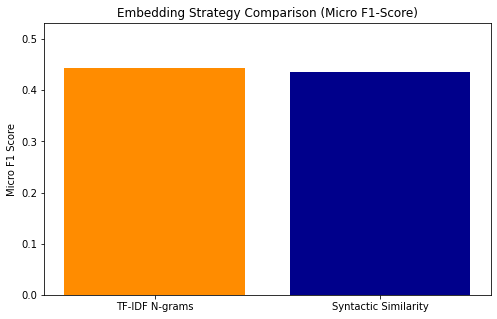

In [9]:


# --- G. Comparison of Embedding Choices ---
# We compare the two embedding strategies by training a simple Logistic Regression 
# model (our baseline) using only the embedding features plus the initial targets (X_targets).

# Model definition (using OneVsRestClassifier for multi-label task)
def get_comparison_model():
    # Use basic Logistic Regression settings for quick CV comparison
    lr = LogisticRegression(solver='liblinear', C=1, random_state=42, max_iter=200)
    return OneVsRestClassifier(lr)

# Scorer: F1-Micro (standard for multi-label comparison)
scorer = make_scorer(f1_score, average='micro')

# 1. Feature Set A: TF-IDF N-grams (Our previous high-dimensional embedding)
X_tfidf_comp = np.hstack([X_targets, X_names.toarray()])

# 2. Feature Set B: Syntactic Similarity (Our new single-feature embedding)
X_sim_comp = np.hstack([X_targets, X_sim])

# Filter targets to match the final training target (top 300 effects)
# This uses the 'y' calculated earlier (unfiltered MultiLabelBinarizer output)
top_300_indices = y.sum(axis=0).argsort()[-300:][::-1]
y_filtered_comp = y[:, top_300_indices]


def evaluate_embedding_strategy(X_comp, y_comp, strategy_name):
    # Use cross-validation (CV=3) for a quick, robust comparison
    model = get_comparison_model()
    # Note: We use the *entire* dataset for CV comparison consistency, 
    # but in full training, you use X_train only.
    scores = cross_val_score(model, X_comp, y_comp, cv=3, scoring=scorer, n_jobs=-1)
    mean_f1 = np.mean(scores)
    print(f"Strategy: {strategy_name}")
    print(f"  Mean Micro F1 Score (CV=3): {mean_f1:.4f}")
    return mean_f1

print("\n--- Running Cross-Validation Comparison (Baseline Model) ---")
f1_tfidf = evaluate_embedding_strategy(X_tfidf_comp, y_filtered_comp, "TF-IDF N-grams (10k+ features)")
f1_sim = evaluate_embedding_strategy(X_sim_comp, y_filtered_comp, "Syntactic Similarity (1 feature)")

# --- H. Final Conclusion Visualization ---
results = {
    'TF-IDF N-grams': f1_tfidf,
    'Syntactic Similarity': f1_sim
}
strategies = list(results.keys())
f1_scores = list(results.values())

plt.figure(figsize=(8, 5))
plt.bar(strategies, f1_scores, color=['darkorange', 'darkblue'])
plt.title('Embedding Strategy Comparison (Micro F1-Score)')
plt.ylim(0, max(f1_scores) * 1.2)
plt.ylabel('Micro F1 Score')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

# # Garder uniquement les 300 effets les plus fréquents
top_300_indices = y.sum(axis=0).argsort()[-300:][::-1]
y_filtered = y[:, top_300_indices]

# Séparation Train / Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X_final, y_filtered, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (841, 11605)
Test shape: (211, 11605)


## GridSearchCV to find optimized parameter to our baseline model (Logistic Regression)

In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score

# 1. Define the base model (suited for multi-label classification)
# We use solver='liblinear' because it handles sparse data and L1/L2 regularization well
base_model = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=42))

# 2. Define the hyperparameter grid
# Note the "estimator__" prefix because the model is encapsulated within OneVsRestClassifier
param_grid = {
    'estimator__C': [0.1, 1, 10],            # Regularization strength
    'estimator__penalty': ['l1', 'l2']       # Regularization type
}

# 3. Configure the Grid Search
# We optimize the 'micro' F1-score, which is standard for imbalanced multi-label classification
scorer = make_scorer(f1_score, average='micro')

grid_search = GridSearchCV(base_model, param_grid, cv=3, scoring=scorer, verbose=2, n_jobs=-1)

# 4. Train (This usually take some time)
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

# 5. Results
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV Score (F1 Micro): {grid_search.best_score_}")

# Save the best model
best_baseline = grid_search.best_estimator_

Starting Grid Search...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ............estimator__C=0.1, estimator__penalty=l1; total time=  21.1s
[CV] END ............estimator__C=0.1, estimator__penalty=l2; total time=  21.6s
[CV] END ............estimator__C=0.1, estimator__penalty=l1; total time=  22.7s
[CV] END ............estimator__C=0.1, estimator__penalty=l2; total time=  22.7s
[CV] END ..............estimator__C=1, estimator__penalty=l2; total time=  22.8s
[CV] END ..............estimator__C=1, estimator__penalty=l2; total time=  23.1s
[CV] END ..............estimator__C=1, estimator__penalty=l1; total time=  23.4s


/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ............estimator__C=0.1, estimator__penalty=l1; total time=  24.9s


...

[CV] END .............estimator__C=10, estimator__penalty=l1; total time=  35.0s


/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number 

[CV] END .............estimator__C=10, estimator__penalty=l1; total time=  44.6s


/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.9/site-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number 

[CV] END .............estimator__C=10, estimator__penalty=l1; total time=  51.0s
Best parameters: {'estimator__C': 10, 'estimator__penalty': 'l2'}
Best CV Score (F1 Micro): 0.4756510212377634


## Bagging method on RandomForestClassifier

In [22]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest gère nativement le multi-output, pas besoin de OneVsRest (souvent plus rapide)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest trained.")

Random Forest trained.


## Voting method on 3 models (LogisticRegression, MultinomialNB and RandomForestClassifier)

In [23]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier

# Définir les classificateurs de base
clf1 = LogisticRegression(solver='liblinear', random_state=1)
clf2 = RandomForestClassifier(n_estimators=50, random_state=1)
clf3 = MultinomialNB()

# Voting 'soft' utilise les probabilités pondérées
voting_clf = OneVsRestClassifier(VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2), ('nb', clf3)],
    voting='soft'
))

voting_clf.fit(X_train, y_train)
print("Voting Classifier entraîné.")

Voting Classifier entraîné.


## Evaluation

--- Performance : Baseline Optimized ---
F1 Micro: 0.4955
F1 Macro: 0.3618
--- Performance : Random Forest ---
F1 Micro: 0.4021
F1 Macro: 0.2842
--- Performance : Voting Classifier ---
F1 Micro: 0.4916
F1 Macro: 0.3172


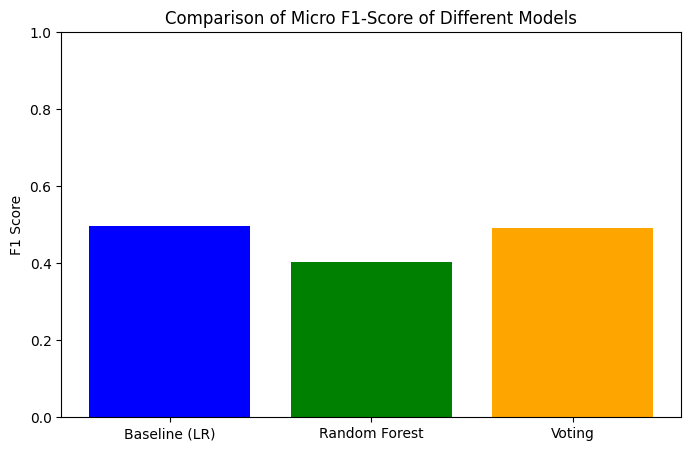

In [24]:
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    
    # Textual report
    print(f"--- Performance : {model_name} ---")
    # print(classification_report(y_test, y_pred, zero_division=0)) # Warning: very long output if 5000 classes
    
    # More concise alternative:
    print(f"F1 Micro: {f1_score(y_test, y_pred, average='micro'):.4f}")
    print(f"F1 Macro: {f1_score(y_test, y_pred, average='macro'):.4f}")
    
    return y_pred

# Comparison
y_pred_baseline = evaluate_model(best_baseline, X_test, y_test, "Baseline Optimized")
y_pred_rf = evaluate_model(rf_model, X_test, y_test, "Random Forest")
y_pred_voting = evaluate_model(voting_clf, X_test, y_test, "Voting Classifier")

# Visualization: Comparison of F1 Scores
models = ['Baseline (LR)', 'Random Forest', 'Voting']
scores = [
    f1_score(y_test, y_pred_baseline, average='micro'),
    f1_score(y_test, y_pred_rf, average='micro'),
    f1_score(y_test, y_pred_voting, average='micro')
]

plt.figure(figsize=(8, 5))
plt.bar(models, scores, color=['blue', 'green', 'orange'])
plt.title('Comparison of Micro F1-Score of Different Models')
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.savefig('model_comparison.png')
plt.show()

We can conclude here that the best model is our optimized baseline model which is the LogisticRegression.\
The performance of this model is quite good for a **multi-label** classification. If we take all side effects in counts (5735 side effects) and we try to guess it randomly we get a score near ~0.0002 (because it's multi-label classification problem, there is a lot of possible combinaison).\
Our model have a score of ~0.50 which is infinitly better than just guessing it randomly. Our model learned to associate n-grams to side effets.

## Exportation : Baseline Model - LogisticRegression

In [25]:
import joblib

# Get the names of the top 300 effects
final_effects_names = mlb_effects.classes_[top_300_indices]

print(f"Number of effects saved: {len(final_effects_names)}")

# Save this LIST (and not the entire mlb_effects)
joblib.dump(final_effects_names, 'models_export/filtered_effects_names.pkl')

# Also save the rest if not done
joblib.dump(best_baseline, 'models_export/best_model.pkl')
joblib.dump(tfidf, 'models_export/tfidf_name.pkl')
joblib.dump(mlb_targets, 'models_export/mlb_targets.pkl')

Number of effects saved: 300


['models_export/mlb_targets.pkl']